0.6425518859657806

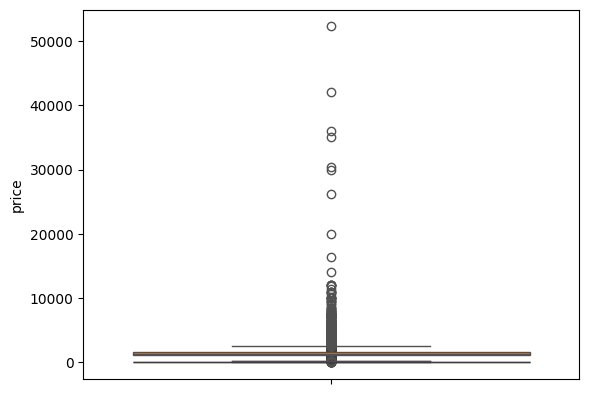

In [1]:
#house price predicton
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df=pd.read_csv("Bengaluru_House_Data (1).csv")

df2=df.copy()
df3=df.copy()
df4=df.copy()
df.isnull().sum()

#categorical
from sklearn.preprocessing import OneHotEncoder



df3.drop(["area_type","availability","society","balcony"],axis=1,inplace=True)


#cleaning of categorical value since there arae too manyy therefore we wil replace rare once with others

df3.dropna(subset=["location"],inplace=True)

df3.isnull().sum()
count=df3.groupby("location")["location"].count().sort_values(ascending=False)
df3["location"]=df3["location"].apply(lambda x:"others" if count[x]<10 else x)
len(df3["location"].unique())

encoder=OneHotEncoder()
encoded=encoder.fit_transform(df3[["location"]]).toarray()
df3_numloc=pd.DataFrame(encoded,columns=encoder.get_feature_names_out())
df3=pd.concat([df3,df3_numloc],axis=1)

df3.drop(["location"],axis=1,inplace=True)
df3.shape


df3["size"]=df3["size"].str.replace("BHK","")
df3["size"]=df3["size"].str.replace("Bedroom","")
df3["size"]=df3["size"].str.replace("RK","")


df3.dropna(inplace=True)
df3.isnull().sum()
df3["size"]=df3["size"].astype(float)


units=["Sq. Meter","Perch","Sq. Yards","Acres","Cents","Guntha","Grounds"]
for u in units:
    df3["total_sqft"]=df3["total_sqft"].str.replace(u,"")






df3["total_sqft"]=df3["total_sqft"].apply(lambda x:(float(x.split('-')[0])+float(x.split('-')[1]))/2 if '-' in str(x) else float(x))
df3["total_sqft"].astype(float)


#dealt with missing value and coverted all into numerical

#delealig wiith outliers
sns.boxplot(df3["price"])
sns.boxplot(df3["total_sqft"])






#iqr method
q1=df3["total_sqft"].quantile(0.25)
q3=df3["total_sqft"].quantile(0.75)
q=q3-q1
lower=q1-(1.5*q)
upper=q3+(1.5*q)


df3.loc[(df3["total_sqft"]<lower),"total_sqft"]=lower
df3.loc[(df3["total_sqft"]>upper),"total_sqft"]=upper

#sns.boxplot(df3["total_sqft"])
#df3.info(object)
col=["bath","price","size"]
for c in col:
    q1=df3[c].quantile(0.25)
    q3=df3[c].quantile(0.75)
    q=q3-q1
    lower=q1-(1.5*q)
    upper=q3+(1.5*q)


    df3.loc[(df3[c]<lower),c]=lower
    df3.loc[(df3[c]>upper),c]=upper


#ml training
#df3.corr()

#independent and dependent
x=df3.drop("price",axis=1)
y=df3["price"]

#train test splt
from sklearn.model_selection import train_test_split
train_x,test_x,train_y,test_y=train_test_split(x,y,test_size=0.25,random_state=42)

#standarzation
from sklearn.preprocessing import StandardScaler
normalize=StandardScaler()
train_x=normalize.fit_transform(train_x)
test_x=normalize.transform(test_x)


#model training
from sklearn.linear_model import LinearRegression
regresison=LinearRegression()
regresison.fit(train_x,train_y)

#cross vlaliation
from sklearn.model_selection import cross_val_score

score=cross_val_score(regresison,train_x,train_y,cv=5,scoring=('r2'))
np.mean(score)


#prediction
y_predict=regresison.predict(test_x)

#r2
from sklearn.metrics import r2_score

r2score=r2_score(test_y,y_predict)
r2score












                    




























